In [1]:
#Path has been added to include the permutation functions
import sys
import os
sys.path.append(os.path.join(os.getcwd() , ".." , "Python_scripts"))

In [2]:
#libraries
import scanpy as sc
import pandas as pd
import numpy as np
import copy
import scipy.stats as st
import seaborn as sns
import matplotlib.pyplot as plt
import random
from permutation import freq_to_link_table , calculate_statistic , run_permutation_parallel
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist

In [3]:
#Set seed
seed_number = 42

random.seed(seed_number)     # python random generator
np.random.seed(seed_number)  # numpy random generator

In [4]:
# ─── EXPERIMENT PARAMETERS — edit these before running ───────────────────────
keep_somites     = ['1-somite', '4-somites', '7-somites']
# annotation_col   = "cell_type_fine"
# annotation_col = "cell_type_coarse"
annotation_col = "cell_type_collapsed"   # pre-computed in R; set use_collapsed=False
use_collapsed    = True   # True → prog (neurons mapped onto progenitor domains)
                          # False + annotation_col="cell_type_collapsed" → standard collapsed

experiment_name = "NT_" + "_".join(s.replace(" ", "") for s in keep_somites)
print(f"Experiment:  {experiment_name}")
print(f"Annotation:  {annotation_col}")

Experiment:  NT_1-somite_4-somites_7-somites
Annotation:  cell_type_collapsed


In [5]:
#Read in meta data
data_path = "/nemo/lab/briscoej/home/users/boeziog/LARRY/"
meta_files = os.path.join(data_path, "metadata")

chicken_meta = pd.read_csv(
    os.path.join(meta_files, "LARRY_NT_integrated_07-09-2025_annotated_metadata.csv")
)

print(chicken_meta.head())
print(chicken_meta.columns)

                index              clone    somites cell_type_fine  \
0  AAACCCATCATGCAGT-1                NaN  7-somites             MN   
1  AAACGAAGTGCGCTCA-1                NaN  7-somites            dp6   
2  AAAGAACTCAGAGCGA-1                NaN  7-somites            dp1   
3  AAAGGATAGAGGATGA-1  clone_2_LIB6512A1  7-somites         pMN/p2   
4  AACAGGGCAACTTGGT-1  clone_5_LIB6512A1  7-somites        dp6/dp5   

  cell_type_coarse cell_type_collapsed  
0           pMN/p2                  MN  
1              dp6                 dp6  
2            dp1/2                 dp1  
3           pMN/p2                 pMN  
4              dp6                 dp6  
Index(['index', 'clone', 'somites', 'cell_type_fine', 'cell_type_coarse',
       'cell_type_collapsed'],
      dtype='object')


In [6]:
print("=== cell_type_fine ===")
print(sorted(chicken_meta['cell_type_fine'].dropna().unique()))
print("\n=== cell_type_coarse ===")
print(sorted(chicken_meta['cell_type_coarse'].dropna().unique()))

=== cell_type_fine ===
['FP', 'MN', 'RP', 'Unclear', 'V0/V1', 'V2', 'V3', 'dI1', 'dI2', 'dI4/6', 'dI5', 'dp1', 'dp2', 'dp3', 'dp3/4', 'dp4/5', 'dp5', 'dp6', 'dp6/dp5', 'p0', 'p0/dp6', 'p0/p1', 'p1', 'p1/p2', 'p2', 'p3', 'pMN', 'pMN/p2', 'pMN/p3']

=== cell_type_coarse ===
['FP', 'RP', 'Unclear', 'dp1/2', 'dp3/5', 'dp6', 'p0/p1', 'p3', 'pMN/p2']


In [7]:
chicken_meta = chicken_meta.rename(columns={annotation_col: 'cell_type'})

In [8]:
# List all unique cell types
print(chicken_meta["cell_type"].unique())


['MN' 'dp6' 'dp1' 'pMN' 'dp4/5' 'p0' 'dI2' 'p1' 'FP' 'dp3' 'Unclear'
 'dI4/dI5' 'p2' 'dI1' 'p3' 'RP' 'V2' 'V0/V1' 'V3' 'dp2' nan]


In [9]:
# Collapse from cell_type_fine regardless of annotation_col
# Neurons mapped onto their progenitor domains
fine_col = "cell_type" if annotation_col == "cell_type_fine" else "cell_type_fine"

chicken_meta_collapsed = chicken_meta.copy()
chicken_meta_collapsed["cell_type"] = chicken_meta_collapsed[fine_col].replace({
    "dp3/4":   "dp4/5",
    "dp5":     "dp4/5",
    "pMN/p2":  "pMN",
    "pMN/p3":  "pMN",
    "p0/p1":   "p0",
    "dp6/dp5": "dp6",
    "p0/dp6":  "dp6",
    "p1/p2":   "p2",
    "dI4/6":   "dp4/5",
    "dI5":     "dp4/5",
    "V0/V1":   "p0",
    "MN":      "pMN",
    "V3":      "p3",
    "dI1":     "dp1",
    "dI2":     "dp2",
    "V2":      "p2",
})

In [10]:
# Cell types of interest
chicken_cell_types_fine = [
    'RP','dI1', 'dI2',
    'dp1', 'dp2', 'dp3', 'dp3/4', 'dp4/5', 'dp5', 'dI4/6', 'dI5', 'dp6/dp5', 'dp6', 'p0/dp6',
    'p0',  'p0/p1', 'p1', 'V0/V1',  'p1/p2', 'p2', 'V2',  'MN',
    'pMN', 'pMN/p2', 'pMN/p3',  'p3', 'V3', 'FP'
]

chicken_cell_types_coarse = [
    'RP', 'dp1/2', 'dp3/5', 'dp6', 'p0/p1', 'pMN/p2', 'p3', 'FP'
]

# Neurons mapped onto progenitor domains
chicken_cell_types_collapsed = [
    'RP', 'dp1', 'dp2',
    'dp3', 'dp4/5', 'dp6',
    'p0', 'p1', 'p2',
    'pMN', 'p3', 'FP'
]

# Select based on annotation_col and use_collapsed
if use_collapsed:
    chicken_cell_types = chicken_cell_types_collapsed
elif annotation_col == "cell_type_fine":
    chicken_cell_types = chicken_cell_types_fine
elif annotation_col == "cell_type_coarse":
    chicken_cell_types = chicken_cell_types_coarse
elif annotation_col == "cell_type_collapsed":
    chicken_cell_types = chicken_cell_types_collapsed

In [11]:
# Filter metadata for interest cell types
chicken_meta_interest = chicken_meta[
    chicken_meta["cell_type"].isin(chicken_cell_types)
]

In [12]:
# Filter by developmental stage
chicken_meta_interest = chicken_meta_interest[chicken_meta_interest['somites'].isin(keep_somites)].copy()

print(f"Cells remaining after somite filter: {len(chicken_meta_interest)}")
print(chicken_meta_interest['somites'].unique())

Cells remaining after somite filter: 5074
['7-somites' '1-somite' '4-somites']


In [13]:
# Set up variables for downstream analysis

if use_collapsed:
    meta_interest       = chicken_meta_collapsed.copy()
    cell_types_interest = chicken_cell_types_collapsed
    analysis_suffix     = "_collapsed"
else:
    meta_interest       = chicken_meta_interest.copy()
    cell_types_interest = chicken_cell_types
    analysis_suffix     = ""

# Apply somite filter
meta_interest = meta_interest[meta_interest['somites'].isin(keep_somites)].copy()
print(f"Cells after somite filter: {len(meta_interest)}")
print(meta_interest['somites'].unique())

Cells after somite filter: 6263
['7-somites' '1-somite' '4-somites']


In [14]:
# Remove cells without a clone, and restrict to cell types in the current analysis
meta_clone = meta_interest[~pd.isna(meta_interest["clone"])]
meta_clone = meta_clone[meta_clone["cell_type"].isin(cell_types_interest)]

In [15]:
# Get amount of cells per clone/Cell type combination
clone_celltype_combo = meta_clone.groupby(["clone", "cell_type"]).size().reset_index(name="amount")
# Reshape data
clone_celltype_combo_wide = clone_celltype_combo.pivot(index="clone", columns="cell_type", values="amount").fillna(0).astype("int")
# Ensure all cell_types_interest are present as columns (fill absent ones with 0)
clone_celltype_combo_wide = clone_celltype_combo_wide.reindex(columns=cell_types_interest, fill_value=0)

In [16]:
#Helper function to save plots recursively
import os
import matplotlib.pyplot as plt

figures_output = os.path.join(
    data_path, "LARRY_spinal_cord", "Jupyter_notebooks", "plots", "chicken", "injHH7-collHH18", experiment_name
)
os.makedirs(figures_output, exist_ok=True)

def save_plot(plot_name):
    interaction_suffix = f"_{type_of_interaction}" if type_of_interaction == "between_within" else ""
    filename = f"{plot_name}{analysis_suffix}{interaction_suffix}.pdf"
    save_path = os.path.join(figures_output, filename)
    plt.savefig(save_path, format="pdf", bbox_inches="tight")
    print(f"✅ Plot saved to {save_path}")


In [17]:
#Option of the permutation function with two possibilities:
## between: excludes interactions between cells of the same type
## between_within: includes interactions between cells of the same type
type_of_interaction = "between_within"

## Jaccard similarity

In [267]:
#Dictionay with celltypes as keys and clone names as values
celltype_clones = {celltype : set(clone_celltype_combo_wide[clone_celltype_combo_wide[celltype] > 0].index) for celltype in clone_celltype_combo_wide.columns}

In [268]:
# Initialize an empty DataFrame
jaccard_matrix = pd.DataFrame(index=cell_types_interest, columns=cell_types_interest, dtype=float)
# Initialize an empty DataFrame
clones_shared = pd.DataFrame(index=cell_types_interest, columns=cell_types_interest, dtype=float)
# Fill in the Jaccard similarity
for k1 in cell_types_interest:
    for k2 in cell_types_interest:
        
        
        
        if k1 == k2:
            jaccard_matrix.loc[k1, k2] = 0
            clones_shared.loc[k1, k2] = clone_celltype_combo_wide[(clone_celltype_combo_wide[k1] > 1)].shape[0]
        else:
            clones_shared.loc[k1, k2] = clone_celltype_combo_wide[(clone_celltype_combo_wide[k1] > 0) & (clone_celltype_combo_wide[k2] > 0)].shape[0]
            intersection = len(celltype_clones[k1] & celltype_clones[k2])
            union = len(celltype_clones[k1] | celltype_clones[k2])
            jaccard = intersection / union if union > 0 else 0
            jaccard_matrix.loc[k1, k2] = np.log(jaccard * 100 + 1e-20)


In [269]:
clones_shared

,RP,dp1,dp2,dp3,dp4/5,dp6,p0,p1,p2,pMN,p3,FP
RP,4.0,4.0,0.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
dp1,4.0,26.0,3.0,6.0,18.0,5.0,5.0,0.0,2.0,1.0,0.0,0.0
dp2,0.0,3.0,1.0,0.0,6.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
dp3,1.0,6.0,0.0,1.0,6.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0
dp4/5,2.0,18.0,6.0,6.0,46.0,15.0,13.0,5.0,1.0,0.0,0.0,0.0
dp6,1.0,5.0,0.0,2.0,15.0,11.0,23.0,8.0,7.0,2.0,0.0,0.0
p0,1.0,5.0,1.0,1.0,13.0,23.0,36.0,25.0,17.0,10.0,0.0,0.0
p1,0.0,0.0,0.0,1.0,5.0,8.0,25.0,11.0,16.0,3.0,0.0,0.0
p2,0.0,2.0,0.0,0.0,1.0,7.0,17.0,16.0,16.0,9.0,0.0,0.0
pMN,0.0,1.0,0.0,0.0,0.0,2.0,10.0,3.0,9.0,40.0,1.0,0.0


✅ Plot saved to /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_7-somites/clone_jaccard_heatmap_collapsed_prog_between_within.pdf


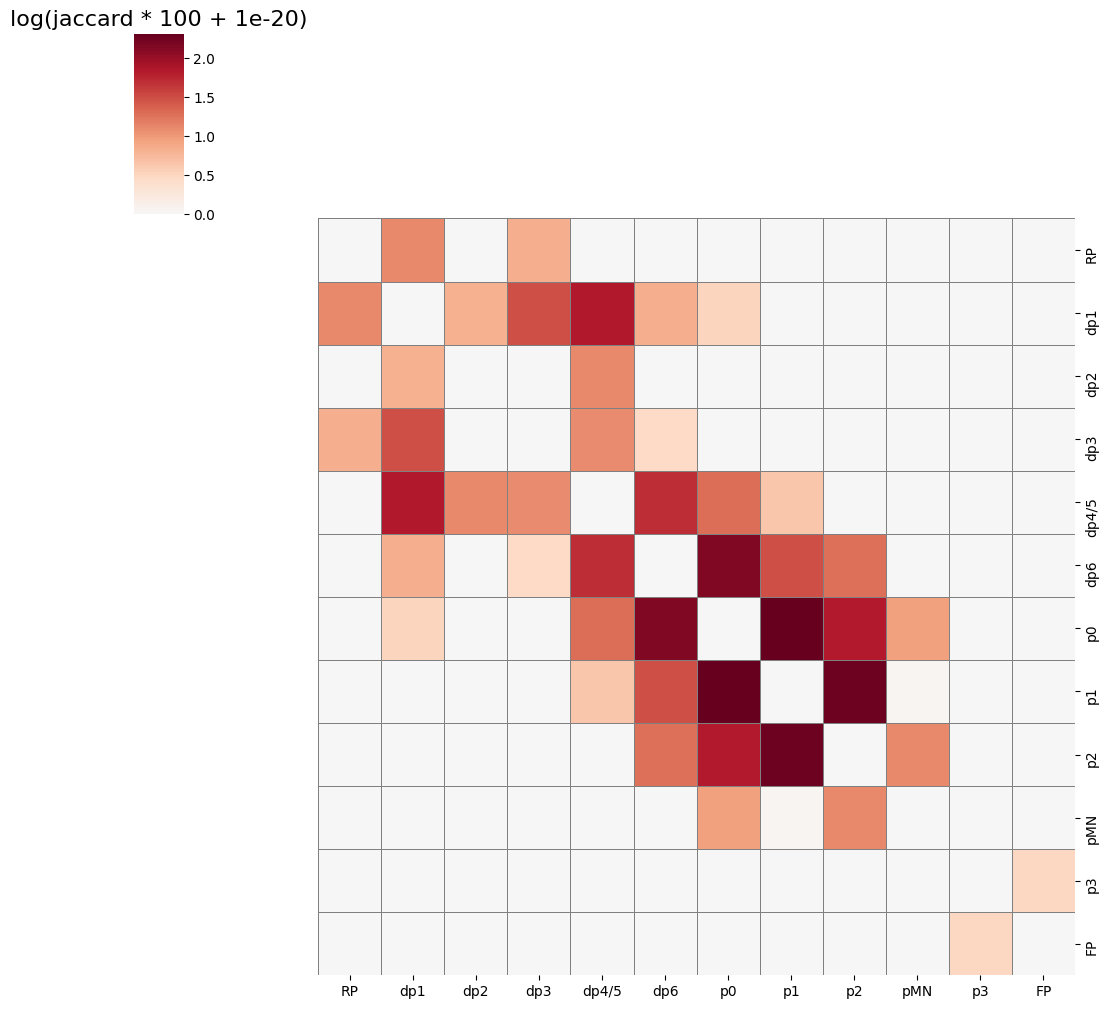

<Figure size 640x480 with 0 Axes>

In [270]:
X = jaccard_matrix

sns.clustermap(
    X,
    cmap='RdBu_r',
    vmin=0,
    center=0,
    row_cluster=False,
    col_cluster=False,
    linewidths=0.5,
    linecolor='grey',
    figsize=(10, 10),
    method="ward"
)

title_text = "log(jaccard * 100 + 1e-20)"
plt.title(title_text, fontsize=16)
save_plot("clone_jaccard_heatmap")
plt.show()
plt.clf()

✅ Plot saved to /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_7-somites/raw_clones_heatmap_collapsed_prog_between_within.pdf


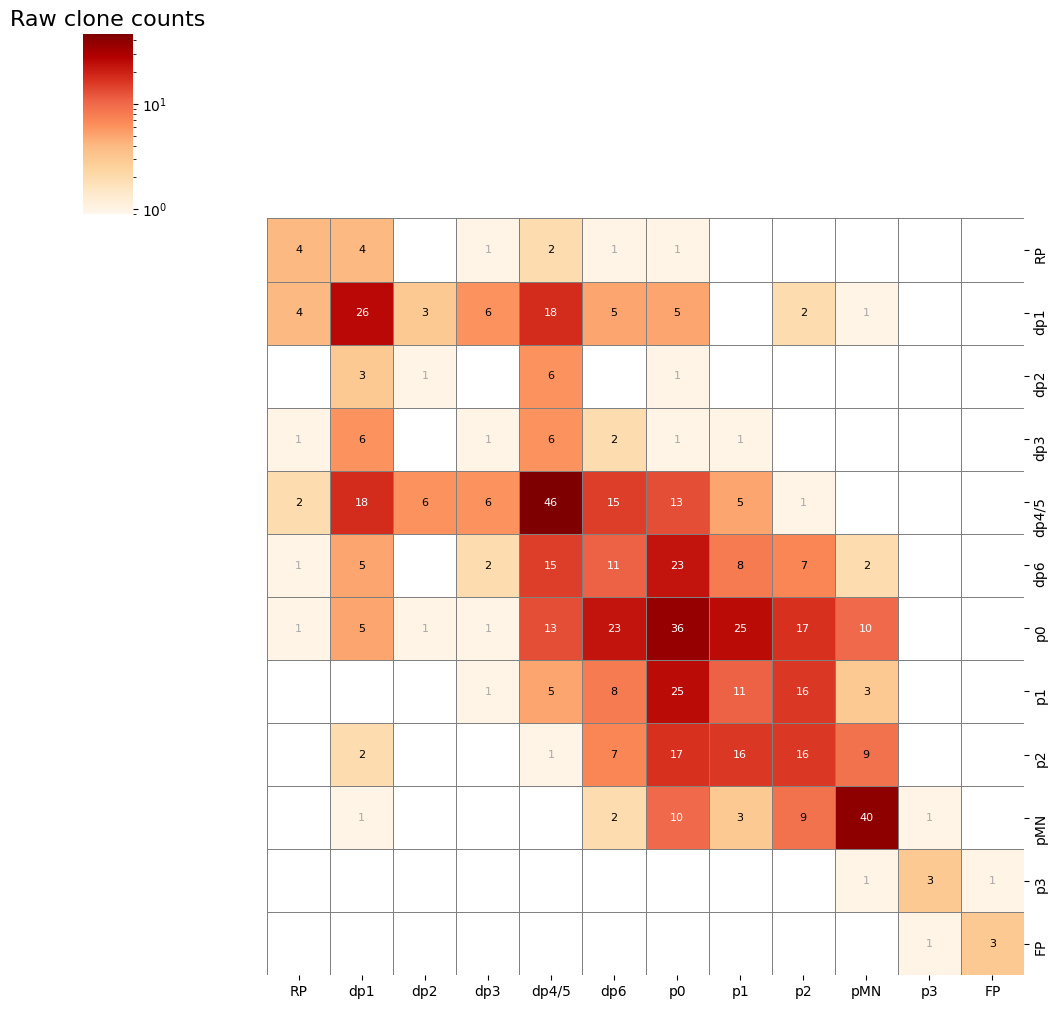

<Figure size 640x480 with 0 Axes>

In [271]:
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm

X = clones_shared

g = sns.clustermap(
    X,
    cmap="OrRd",
    norm=LogNorm(vmin=0.9, vmax=clones_shared.max().max()),
    row_cluster=False,
    col_cluster=False,
    linewidths=0.5,
    linecolor='grey',
    figsize=(10, 10)
)

data = g.data2d.values
ax = g.ax_heatmap

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if val > 0 and np.isclose(val, round(val)):
            if val == 1:
                text_color = 'darkgray'
            elif val < 10:
                text_color = 'black'
            else:
                text_color = 'white'
            ax.text(j + 0.5, i + 0.5, str(int(round(val))),
                    ha='center', va='center',
                    color=text_color, fontsize=8,
                    transform=ax.transData)

title_text = "Raw clone counts"
plt.title(title_text, fontsize=16)
save_plot("raw_clones_heatmap")
plt.show()
plt.clf()

## Permutation test

In [272]:
#Number of permutations
number_permutations = 1000

In [273]:
#Option of the permutation function with two possibilities:
## between: excludes interactions between cells of the same type
## between_within: includes interactions between cells of the same type
type_of_interaction = "between_within"

In [274]:
#Option of the permutation function with four options
## combination: The weight of the connection between two different cell types within a clones is the product of their amount.
## min_link: The weight of the connection between two different cell types within a clones is the minimum of their amount.
## sum: The weight of the connection between two different cell types within a clones is the sum of their amount, both amounts should be bigger than 0.
## connection: The weight of the connection between two different cell types within a clones is 1/0, based on the presence/absence of their co-occurrence. 
cell_combo_method = "sum"

In [275]:
#Calculate the pairwise connection frequency table for our data
interaction_table = freq_to_link_table(clone_celltype_combo_wide , interaction_type = type_of_interaction ,cell_combo_method = cell_combo_method)

In [276]:
#Calculate test statistic for our data
statistic = calculate_statistic(interaction_table)

In [277]:
#Run permutation tests
permutation_results  = run_permutation_parallel(clone_celltype_combo_wide , type_of_interaction , n_jobs = 32 , cell_combo_method = cell_combo_method , number_permutations = number_permutations)

Processing elements: 100%|██████████| 1000/1000 [00:40<00:00, 24.53it/s]


In [278]:
#Calculate statistics in respect to permutation distribution
FC_data = pd.DataFrame({"observed_statistic" : statistic.values() , 'permutation_mean' : np.mean(pd.DataFrame(permutation_results),axis = 0),'permutation_std' : np.std(pd.DataFrame(permutation_results),axis = 0) , 'permutation_max' : pd.DataFrame(permutation_results).max() , 'permutation_min' : pd.DataFrame(permutation_results).min()})

#Calculate Fold Change
FC_data["FC"] = FC_data["observed_statistic"] / FC_data["permutation_mean"] 

#Min Max normalisation
FC_data["min_max_norm"] = (FC_data["observed_statistic"] - FC_data["permutation_min"]) / (FC_data["permutation_max"] - FC_data["permutation_min"])

#Z score
FC_data["zscore"] = (FC_data["observed_statistic"] - FC_data["permutation_mean"]) / (FC_data["permutation_std"])

In [279]:
#Statistic of choice
stat_choice = "zscore"
zscores = {combo: 0 if np.isnan(FC) else FC for combo , FC in zip(FC_data.index , FC_data[stat_choice] )}

### Plot z-score matrix

In [280]:
plot_order = cell_types_interest

# Build z-score matrix
zscore_matrix = pd.DataFrame(index=plot_order, columns=plot_order)
for combination, zscore in zscores.items():
    el1, el2 = combination.split("|")
    zscore_matrix.at[el1, el2] = zscore
    zscore_matrix.at[el2, el1] = zscore

# Build correlation matrix
lineag_coupling_corr = pd.DataFrame(index=zscore_matrix.columns, columns=zscore_matrix.columns)
cell_types = zscore_matrix.columns

for cell_type_len in range(len(cell_types)):
    for cell_type_2 in cell_types[cell_type_len:]:
        cell_type_1 = cell_types[cell_type_len]
        one = pd.to_numeric(zscore_matrix[cell_type_1], errors='coerce')
        two = pd.to_numeric(zscore_matrix[cell_type_2], errors='coerce')
        valid_idx = one.notna() & two.notna()
        one_clean = one[valid_idx]
        two_clean = two[valid_idx]
        if len(one_clean) > 1:
            r = st.pearsonr(one_clean, two_clean).statistic
        else:
            r = np.nan
        lineag_coupling_corr.at[cell_type_1, cell_type_2] = r
        lineag_coupling_corr.at[cell_type_2, cell_type_1] = r

In [281]:
#Fill the NA valuesx
X = np.array(zscore_matrix.fillna(0))

✅ Plot saved to /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_7-somites/clone_zscore_heatmap_collapsed_prog_between_within.pdf


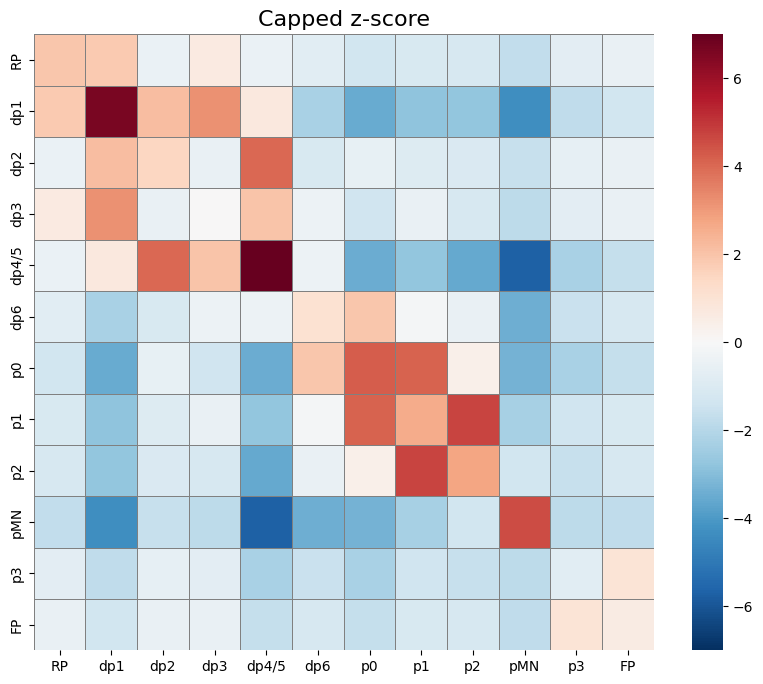

<Figure size 640x480 with 0 Axes>

In [282]:
#Fill the NA values
X = np.array(zscore_matrix.fillna(0))

plt.figure(figsize=(10, 8))

mask = np.array(clones_shared) < 1


# Base layer: low alpha (faded values for all cells)
sns.heatmap(
    X,
    cmap='RdBu_r',
    vmin=-7,
    vmax=7,
    center=0,
    linewidths=0.5,
    linecolor='grey',
    xticklabels=plot_order,
    yticklabels=plot_order,
    alpha=0.1,
    cbar=False
)


# Top layer: high alpha, mask low-confidence cells
sns.heatmap(
    X,
    #mask=mask,
    cmap='RdBu_r',
    vmin=-7,
    vmax=7,
    center=0,
    linewidths=0.5,
    linecolor='grey',
    xticklabels=plot_order,
    yticklabels=plot_order,
    alpha=1.0
)


title_text = "Capped z-score"

# Set the title
plt.title(title_text, fontsize=16)


save_plot("clone_zscore_heatmap")

# Then show/clear
plt.show()
plt.clf()


### Plot correlation matrix

✅ Plot saved to /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_7-somites/clone_correlation_heatmap_collapsed_prog_between_within.pdf


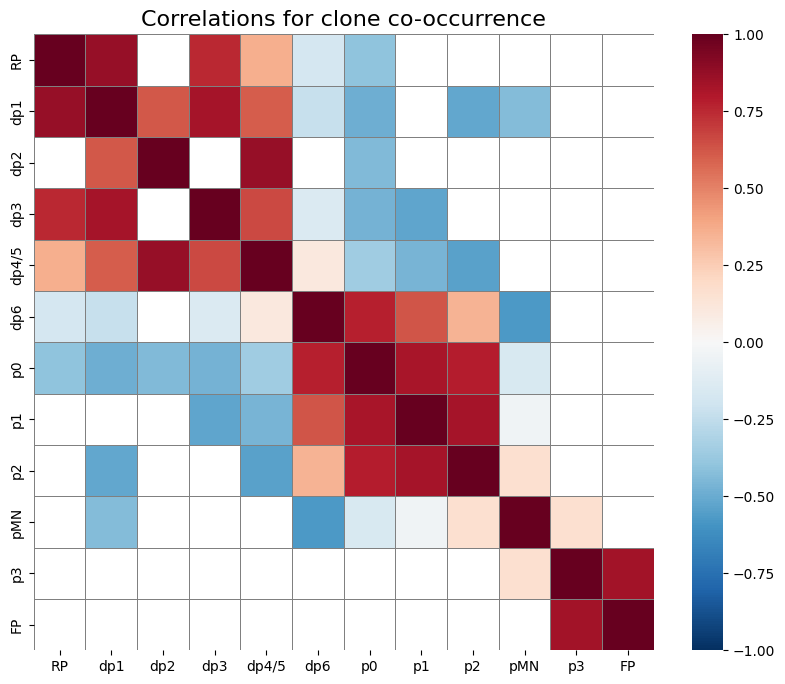

<Figure size 640x480 with 0 Axes>

In [283]:
X = np.array(lineag_coupling_corr.fillna(0))

plt.figure(figsize=(10, 8))
mask = np.array(clones_shared) < 1

sns.heatmap(X,
            mask=mask,
            linewidths=0.5, linecolor='grey',
            alpha=1.0,
            xticklabels=plot_order, yticklabels=plot_order,
            vmin=-1, vmax=1, cmap='RdBu_r', center=0)

plt.title("Correlations for clone co-occurrence", fontsize=16)
save_plot("clone_correlation_heatmap")
plt.show()
plt.clf()

### Plot correlation matrix with corresponding z-score
Correlation matrix and z-score values must have the same sign. otherwise they are taken out.

In [284]:
#Compare zscore sign with correlation sign
same_sign = np.sign(lineag_coupling_corr) == np.sign(zscore_matrix.fillna(0))

✅ Plot saved to /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_7-somites/clone_correlation_concordant_heatmap_collapsed_prog_between_within.pdf


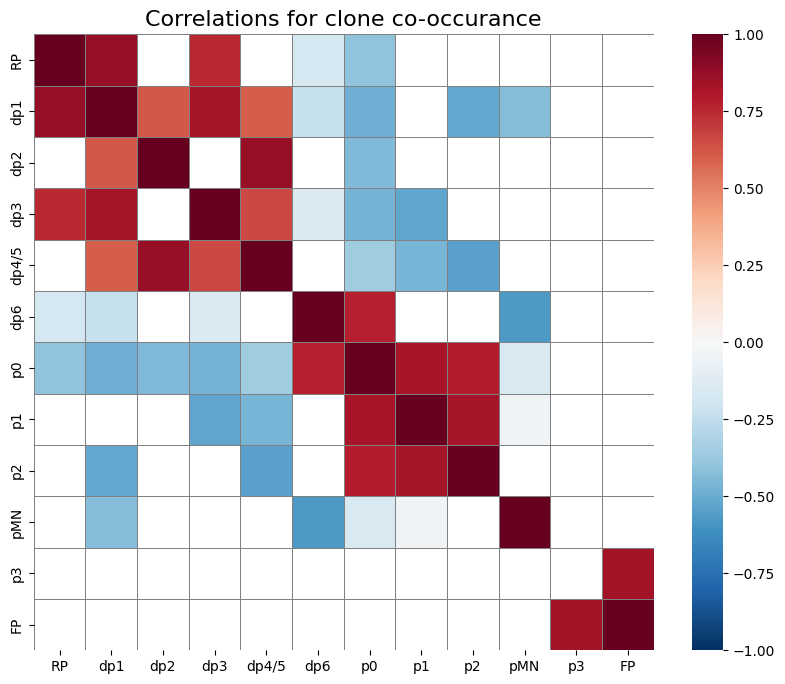

<Figure size 640x480 with 0 Axes>

In [285]:
#Only correlation with corresponding zscore sign
corresponding_sign = lineag_coupling_corr.where(same_sign)

#Fill the NA values
X = np.array(lineag_coupling_corr.where(same_sign), dtype = float)

# mask = np.isnan(X)
mask = np.array(clones_shared) < 1

plt.figure(figsize=(10, 8))

sns.heatmap(X, alpha=1.0, 
            mask = mask,
            linewidths=0.5,linecolor='grey',xticklabels = plot_order , yticklabels = plot_order, vmin=-1, vmax=1 , cmap='RdBu_r', center=0)
#plt.gca().set_facecolor('whitesmoke')

title_text = "Correlations for clone co-occurance"

# Set the title for the colorbar
plt.title(title_text, fontsize=16)

save_plot("clone_correlation_concordant_heatmap")

plt.show()
plt.clf()

### Hierarchical clustering of zscore

In [ ]:
#Fill the NA values
X = zscore_matrix.fillna(0)

# Overlay heatmap for significant values with higher alpha
mask = np.array(clones_shared) < 2

sns.clustermap(
    X,
    mask = mask,
    cmap='RdBu_r',
    vmin=-5,
    vmax=5,
    center=0,
    row_cluster=True,
    col_cluster=True,
    linewidths=0.5,
    linecolor='grey',
    figsize=(10, 10),
    method = "ward"
)

title_text = "Capped z-score"

# Set the title
plt.title(title_text, fontsize=16)

save_plot("clone_hierarhical_zscore_heatmap")

plt.show()
plt.clf()

### Hierarchical clustering of correlation matrix with corresponding z-score

In [ ]:
# 1. Fill the NA values
X = lineag_coupling_corr.where(same_sign)

X_fillna = X.fillna(0)

# 2. Compute linkage
all_linkage = linkage(pdist(X_fillna.values), method='ward')

In [131]:

# 3. Define recursive resolve function
def resolve(cluster_id, labels, linkage_matrix):
    """
    Recursively resolve the members of a cluster by ID using the linkage matrix.

    Parameters:
    - cluster_id: int, cluster index (>= len(labels) means non-leaf)
    - labels: list of leaf labels (e.g., cell types)
    - linkage_matrix: the hierarchical clustering linkage matrix

    Returns:
    - list of leaf labels in this cluster
    """
    if cluster_id < len(labels):
        return [labels[cluster_id]]
    else:
        cluster_id -= len(labels)
        left = int(linkage_matrix[cluster_id][0])
        right = int(linkage_matrix[cluster_id][1])
        return resolve(left, labels, linkage_matrix) + resolve(right, labels, linkage_matrix)

# 4. Inspect clusters (e.g., bottom-up or top-down)
labels = X_fillna.columns.tolist()
n = len(labels)

print("=== Inspecting last few cluster merges ===")
for i in reversed(range(n, len(all_linkage) + n)):
    members = resolve(i, labels, all_linkage)
    print(f"Row {i - n}: {members}")

=== Inspecting last few cluster merges ===
Row 22: ['dI3', 'dpL', 'dI4', 'dI2', 'dI1', 'dp1', 'dp2', 'pMN', 'MN', 'RP', 'p3/latFP', 'FP', 'p3', 'V3', 'p2', 'V2a', 'V2b', 'dI5', 'dI6', 'p1', 'dp6', 'V0', 'p0', 'V1']
Row 21: ['pMN', 'MN', 'RP', 'p3/latFP', 'FP', 'p3', 'V3', 'p2', 'V2a', 'V2b', 'dI5', 'dI6', 'p1', 'dp6', 'V0', 'p0', 'V1']
Row 20: ['p2', 'V2a', 'V2b', 'dI5', 'dI6', 'p1', 'dp6', 'V0', 'p0', 'V1']
Row 19: ['dI3', 'dpL', 'dI4', 'dI2', 'dI1', 'dp1', 'dp2']
Row 18: ['pMN', 'MN', 'RP', 'p3/latFP', 'FP', 'p3', 'V3']
Row 17: ['RP', 'p3/latFP', 'FP', 'p3', 'V3']
Row 16: ['dI5', 'dI6', 'p1', 'dp6', 'V0', 'p0', 'V1']
Row 15: ['p3/latFP', 'FP', 'p3', 'V3']
Row 14: ['p1', 'dp6', 'V0', 'p0', 'V1']
Row 13: ['dp6', 'V0', 'p0', 'V1']
Row 12: ['p3', 'V3']
Row 11: ['dI2', 'dI1', 'dp1', 'dp2']
Row 10: ['V0', 'p0', 'V1']
Row 9: ['dI5', 'dI6']
Row 8: ['dI3', 'dpL', 'dI4']
Row 7: ['p0', 'V1']
Row 6: ['p2', 'V2a', 'V2b']
Row 5: ['dpL', 'dI4']
Row 4: ['V2a', 'V2b']
Row 3: ['pMN', 'MN']
Row 2: ['p3

In [125]:
#If need to swap more, run each of these block and then inspect
#Blocks for all chicken
tmp = all_linkage[2].copy()
all_linkage[2] = all_linkage[3]
all_linkage[3] = tmp

In [126]:
tmp = all_linkage[7].copy()
all_linkage[7] = all_linkage[9]
all_linkage[9] = tmp

In [127]:
tmp = all_linkage[7].copy()
all_linkage[7] = all_linkage[11]
all_linkage[11] = tmp

In [128]:
tmp = all_linkage[14].copy()
all_linkage[14] = all_linkage[16]
all_linkage[16] = tmp

In [129]:
for i in range(22):  # adjust range to see more
    cluster = resolve(i + len(X_fillna), X_fillna.columns.tolist(), all_linkage)
    print(f"Row {i}: {cluster}")

Row 0: ['dp1', 'dp2']
Row 1: ['dI1', 'dp1', 'dp2']
Row 2: ['pMN', 'MN']
Row 3: ['p3/latFP', 'FP']
Row 4: ['V2a', 'V2b']
Row 5: ['dpL', 'dI4']
Row 6: ['p2', 'V2a', 'V2b']
Row 7: ['dI2', 'dI1', 'dp1', 'dp2']
Row 8: ['dI3', 'dpL', 'dI4']
Row 9: ['p0', 'V1']
Row 10: ['V0', 'dI2', 'dI1', 'dp1', 'dp2']
Row 11: ['dI5', 'dI6']
Row 12: ['p3', 'V3']
Row 13: ['dp6', 'V0', 'dI2', 'dI1', 'dp1', 'dp2']


RecursionError: maximum recursion depth exceeded while calling a Python object

✅ Plot saved to /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/HH24/clone_hierarhical_correlation_concordant_heatmap_collapsed_between_within.pdf


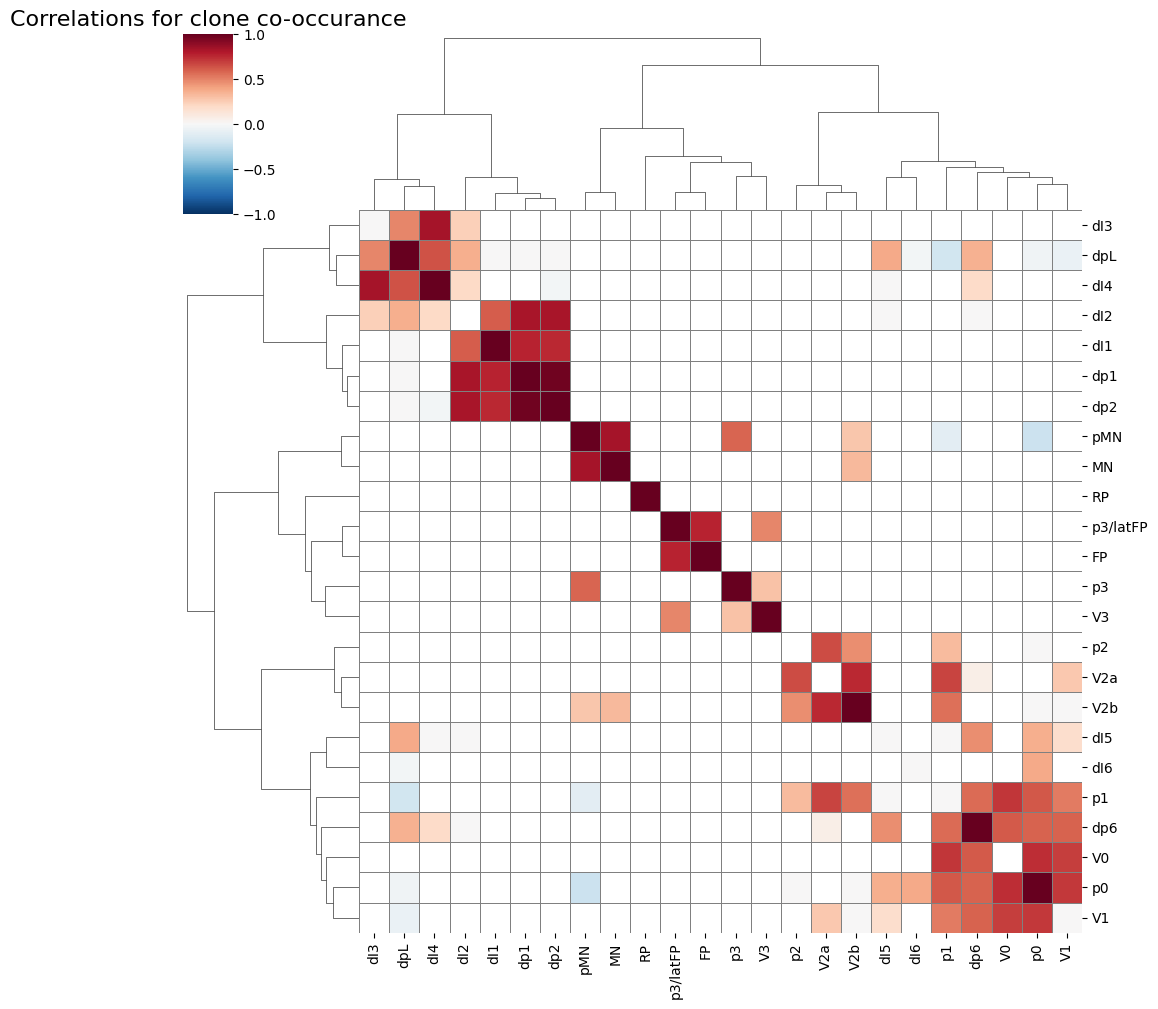

<Figure size 640x480 with 0 Axes>

In [132]:
## Overlay heatmap for significant values with higher alpha
mask = np.array(clones_shared) < 2
sns.clustermap(
    X_fillna,
    mask = mask,
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    center=0,
    row_linkage = all_linkage,
    col_linkage = all_linkage,
    row_cluster=True,
    col_cluster=True,
    linewidths=0.5,
    linecolor='grey',
    figsize=(10, 10),
    method = "ward"
)

title_text = "Correlations for clone co-occurance"

# Set the title
plt.title(title_text, fontsize=16)

save_plot("clone_hierarhical_correlation_concordant_heatmap")
plt.show()
plt.clf()

# Sankey plots

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_Sub_1_collapsed.pdf


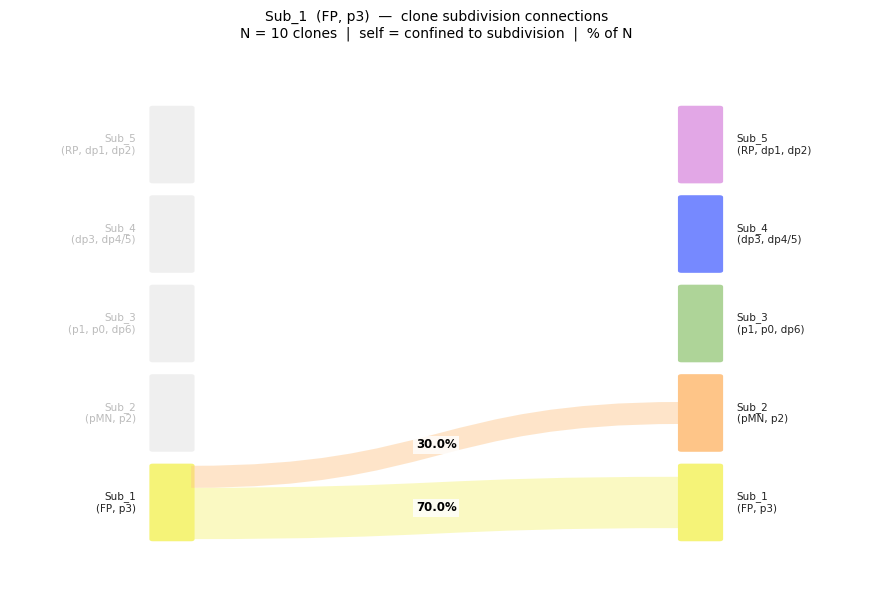

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_Sub_2_collapsed.pdf


<Figure size 640x480 with 0 Axes>

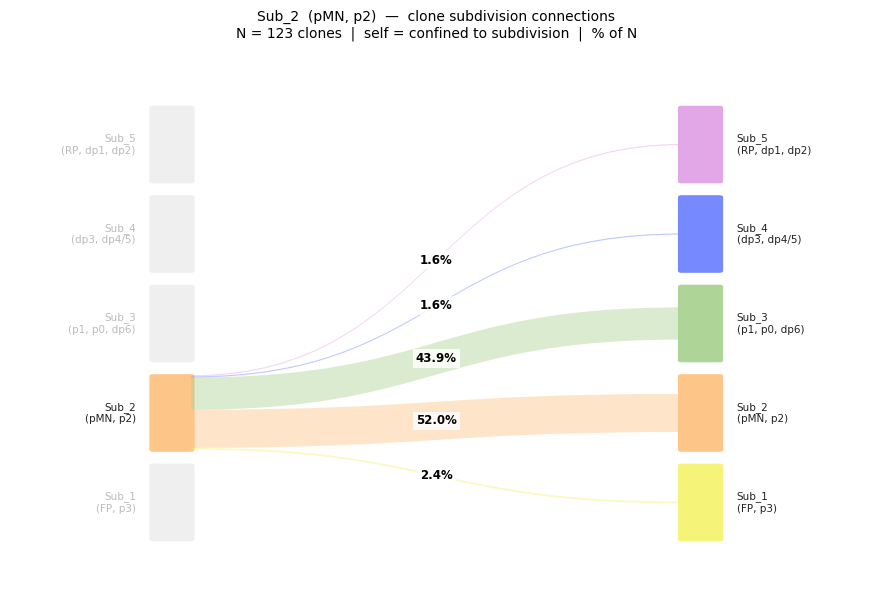

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_Sub_3_collapsed.pdf


<Figure size 640x480 with 0 Axes>

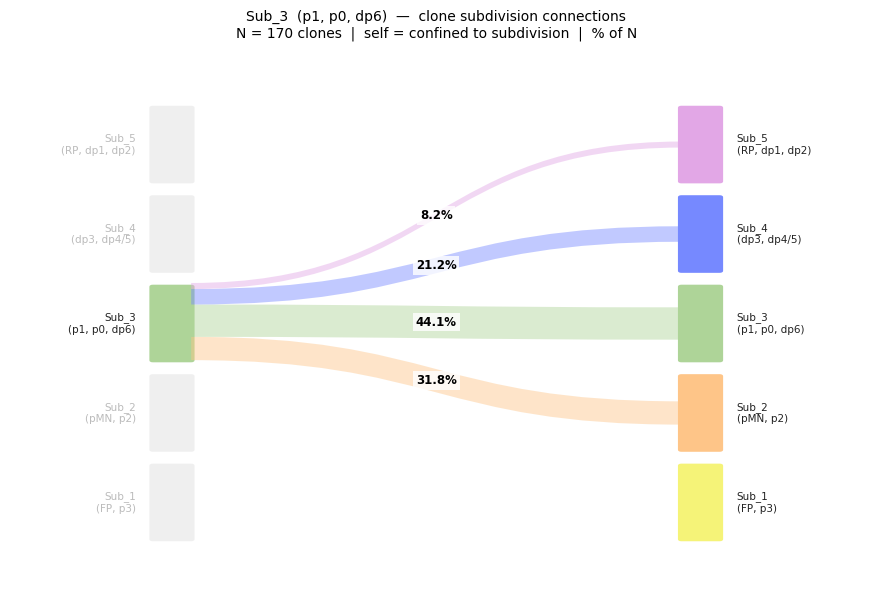

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_Sub_4_collapsed.pdf


<Figure size 640x480 with 0 Axes>

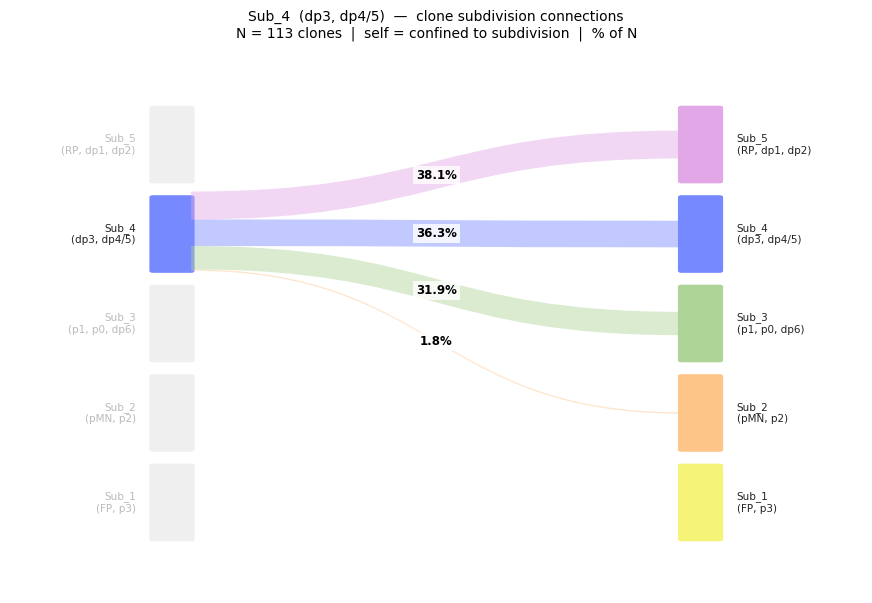

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_Sub_5_collapsed.pdf


<Figure size 640x480 with 0 Axes>

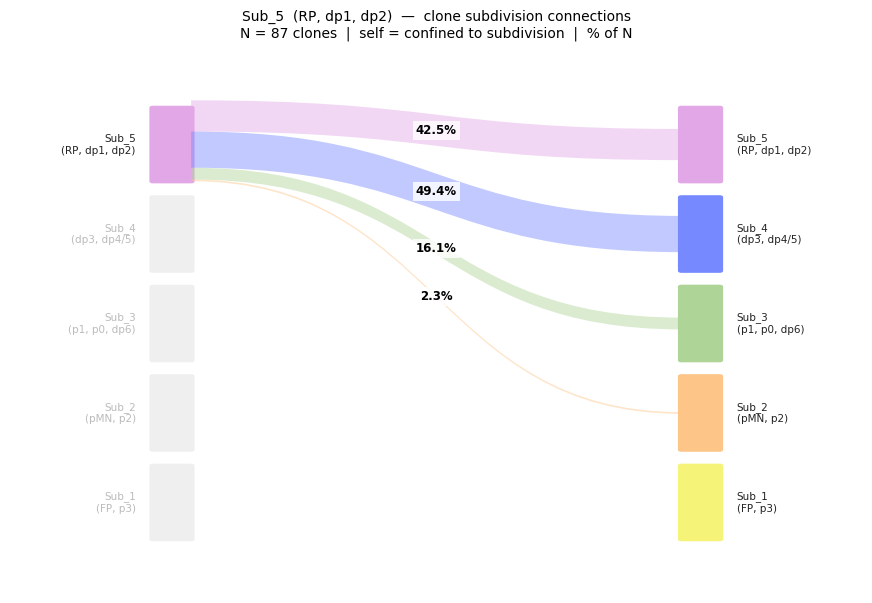

<Figure size 640x480 with 0 Axes>

In [18]:
from matplotlib.path import Path
import matplotlib.patches as mpatches

# ── Subdivision map (filtered to active cell types) ───────────────────────────
_full_sub_map = {
    "FP":      "Sub_1", "V3":      "Sub_1", "p3":      "Sub_1",
    "MN":      "Sub_2", "pMN":     "Sub_2", "p2":      "Sub_2", "V2":      "Sub_2",
    "p1":      "Sub_3", "p0":      "Sub_3", "V0/V1":   "Sub_3", "dp6":     "Sub_3",
    "dp3":     "Sub_4", "dp4/5":   "Sub_4", "dI4/dI5": "Sub_4",
    "RP":      "Sub_5", "dI1":     "Sub_5", "dI2":     "Sub_5",
    "dp1":     "Sub_5", "dp2":     "Sub_5",
}
sub_map_active = {ct: sub for ct, sub in _full_sub_map.items() if ct in cell_types_interest}

# sub_palette = {
#     "Sub_1": "#EDC948", "Sub_2": "#F28E2B", "Sub_3": "#59A14F",
#     "Sub_4": "#4E79A7", "Sub_5": "#B07AA1",
# }

sub_palette = {
    "Sub_1": "#f5f378",   # pale yellow
    "Sub_2": "#fec588",   # peach orange
    "Sub_3": "#aed498",   # sage green
    "Sub_4": "#7689ff",   # periwinkle blue
    "Sub_5": "#e2a7e6",   # lavender pink
}

sub_members = {}
for ct, sub in sub_map_active.items():
    sub_members.setdefault(sub, []).append(ct)

sub_order = [s for s in ["Sub_1", "Sub_2", "Sub_3", "Sub_4", "Sub_5"] if s in sub_members]
sub_labels = {s: f"{s}\n({', '.join(sub_members[s])})" for s in sub_order}

# ── Multi-cell data for subdivisions ─────────────────────────────────────────
_sub_cols = [c for c in clone_celltype_combo_wide.columns if c in sub_map_active]
cn_sub = clone_celltype_combo_wide[_sub_cols].copy()
cn_sub = cn_sub[cn_sub.sum(axis=1) >= 2]
for sub in sub_order:
    members_here = [c for c in sub_members[sub] if c in cn_sub.columns]
    cn_sub[f"n_{sub}"] = cn_sub[members_here].sum(axis=1) if members_here else 0

# ── Bezier band helper ─────────────────────────────────────────────────────────
def _bezier_band(ax, x0, y0b, y0t, x1, y1b, y1t, color, alpha=0.45):
    cx = (x0 + x1) / 2
    verts = [
        (x0, y0b), (cx, y0b), (cx, y1b), (x1, y1b),
        (x1, y1t), (cx, y1t), (cx, y0t), (x0, y0t), (x0, y0b),
    ]
    codes = [Path.MOVETO,
             Path.CURVE4, Path.CURVE4, Path.CURVE4,
             Path.LINETO,
             Path.CURVE4, Path.CURVE4, Path.CURVE4,
             Path.CLOSEPOLY]
    ax.add_patch(mpatches.PathPatch(Path(verts, codes),
                                    facecolor=color, edgecolor="none", alpha=alpha))

# ── Subdivision Sankey ─────────────────────────────────────────────────────────
def draw_subdivision_sankey(focal_sub):
    focal_clones = cn_sub[cn_sub[f"n_{focal_sub}"] >= 1]
    N_total = len(focal_clones)
    if N_total == 0:
        print(f"No clones for {focal_sub}, skipping.")
        return

    counts = {}
    for t in sub_order:
        if t == focal_sub:
            other = [f"n_{s}" for s in sub_order if s != focal_sub]
            counts[t] = int((focal_clones[other].sum(axis=1) == 0).sum())
        else:
            counts[t] = int((focal_clones[f"n_{t}"] >= 1).sum())
    pcts = {t: 100 * counts[t] / N_total for t in sub_order}

    n = len(sub_order)
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")

    nw = 0.45; xl, xr = 1.9, 8.1; y0 = 1.0; total_h = 8.0; gap = 0.3
    nh = (total_h - (n - 1) * gap) / n
    ybot = [y0 + i * (nh + gap) for i in range(n)]
    ycen = [yb + nh / 2 for yb in ybot]
    idx  = {s: i for i, s in enumerate(sub_order)}

    for i, sub in enumerate(sub_order):
        is_focal = sub == focal_sub
        ax.add_patch(mpatches.FancyBboxPatch(
            (xl - nw / 2, ybot[i]), nw, nh, boxstyle="round,pad=0.04",
            facecolor=sub_palette[sub] if is_focal else "#CCCCCC",
            edgecolor="none", alpha=1.0 if is_focal else 0.3,
        ))
        ax.text(xl - nw / 2 - 0.2, ycen[i], sub_labels[sub], ha="right", va="center",
                fontsize=7.5, color="#222222" if is_focal else "#BBBBBB")

    for i, sub in enumerate(sub_order):
        ax.add_patch(mpatches.FancyBboxPatch(
            (xr - nw / 2, ybot[i]), nw, nh, boxstyle="round,pad=0.04",
            facecolor=sub_palette[sub], edgecolor="none",
        ))
        ax.text(xr + nw / 2 + 0.2, ycen[i], sub_labels[sub],
                ha="left", va="center", fontsize=7.5, color="#222222")

    scale = nh / N_total
    left_cursor = ybot[idx[focal_sub]]
    for t in sub_order:
        c = counts[t]
        if c == 0:
            continue
        fh = c * scale
        ti = idx[t]
        ly_b, ly_t = left_cursor, left_cursor + fh
        ry_b, ry_t = ycen[ti] - fh / 2, ycen[ti] + fh / 2
        _bezier_band(ax, xl + nw / 2, ly_b, ly_t, xr - nw / 2, ry_b, ry_t,
                     color=sub_palette[t], alpha=0.45)
        mid_y = ((ly_b + ly_t) / 2 + (ry_b + ry_t) / 2) / 2
        ax.text(5.0, mid_y, f"{pcts[t]:.1f}%", ha="center", va="center",
                fontsize=8.5, fontweight="bold",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=2))
        left_cursor += fh

    ax.set_title(
        f"{focal_sub}  ({', '.join(sub_members[focal_sub])})  —  clone subdivision connections\n"
        f"N = {N_total} clones  |  self = confined to subdivision  |  % of N",
        fontsize=10, pad=12,
    )
    fname = os.path.join(figures_output, f"sankey_{focal_sub}{analysis_suffix}.pdf")
    plt.savefig(fname, format="pdf", bbox_inches="tight")
    print(f"Saved: {fname}")
    plt.show(); plt.clf()


for fs in sub_order:
    draw_subdivision_sankey(fs)

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_celltype_FP_collapsed.pdf


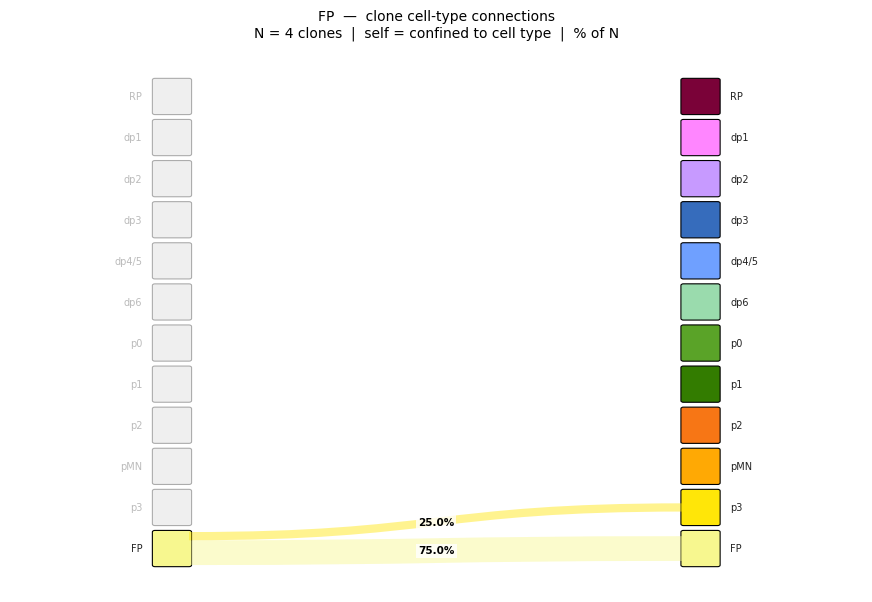

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_celltype_p3_collapsed.pdf


<Figure size 640x480 with 0 Axes>

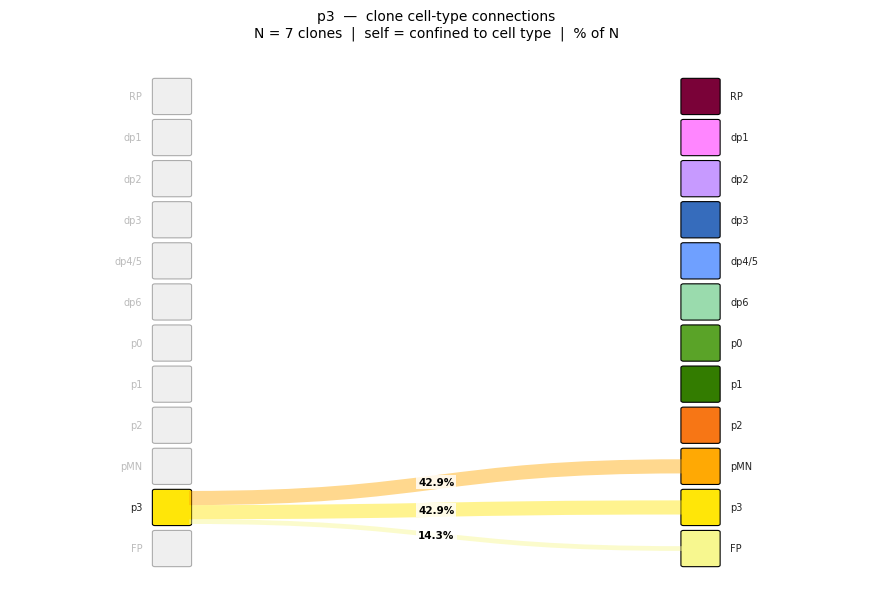

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_celltype_pMN_collapsed.pdf


<Figure size 640x480 with 0 Axes>

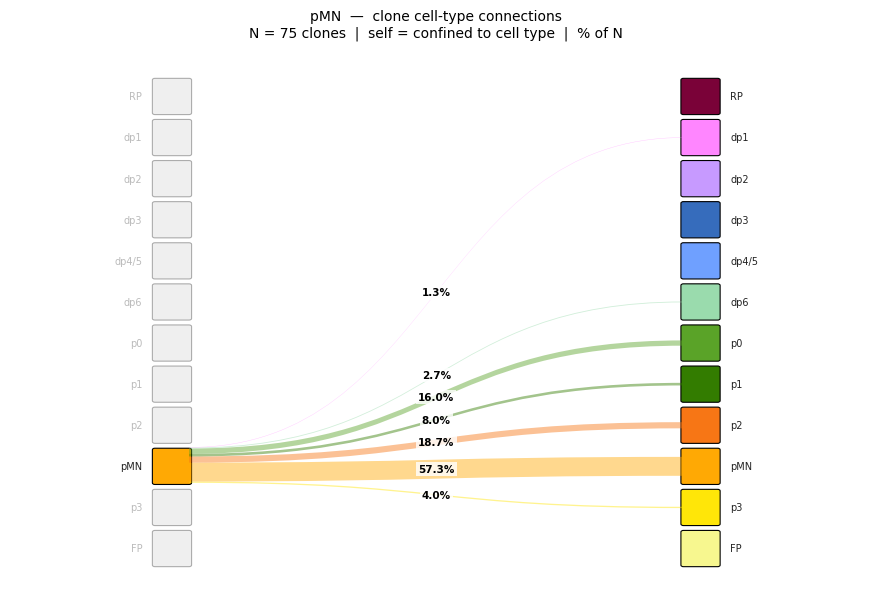

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_celltype_p2_collapsed.pdf


<Figure size 640x480 with 0 Axes>

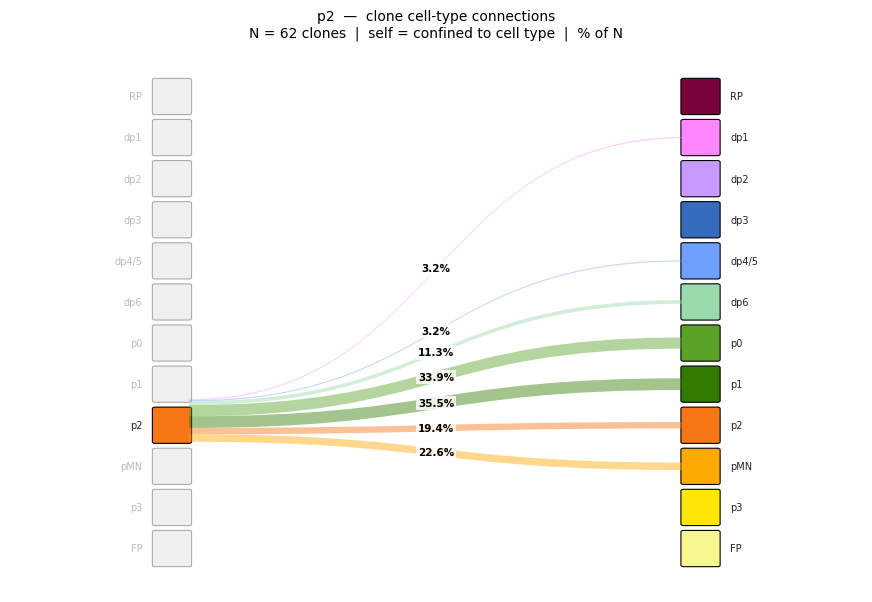

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_celltype_p1_collapsed.pdf


<Figure size 640x480 with 0 Axes>

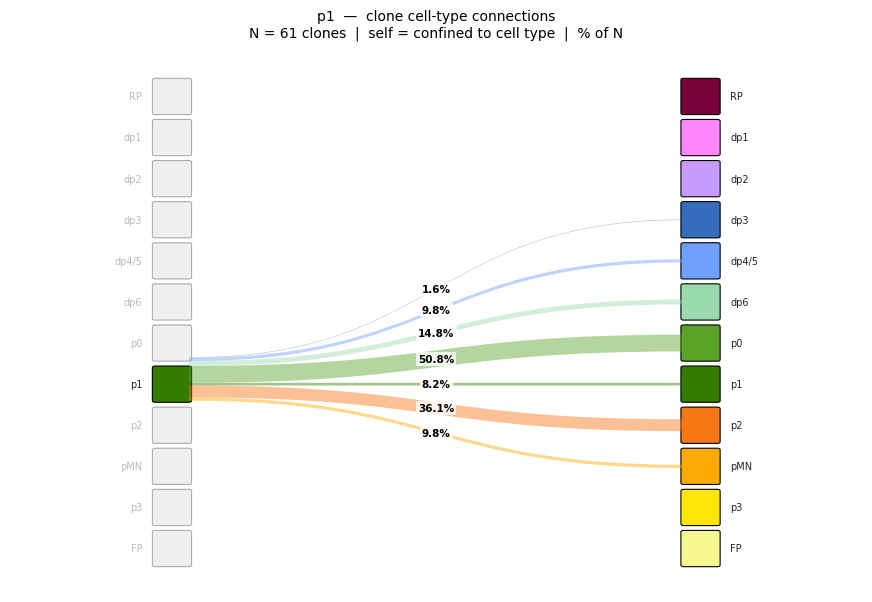

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_celltype_p0_collapsed.pdf


<Figure size 640x480 with 0 Axes>

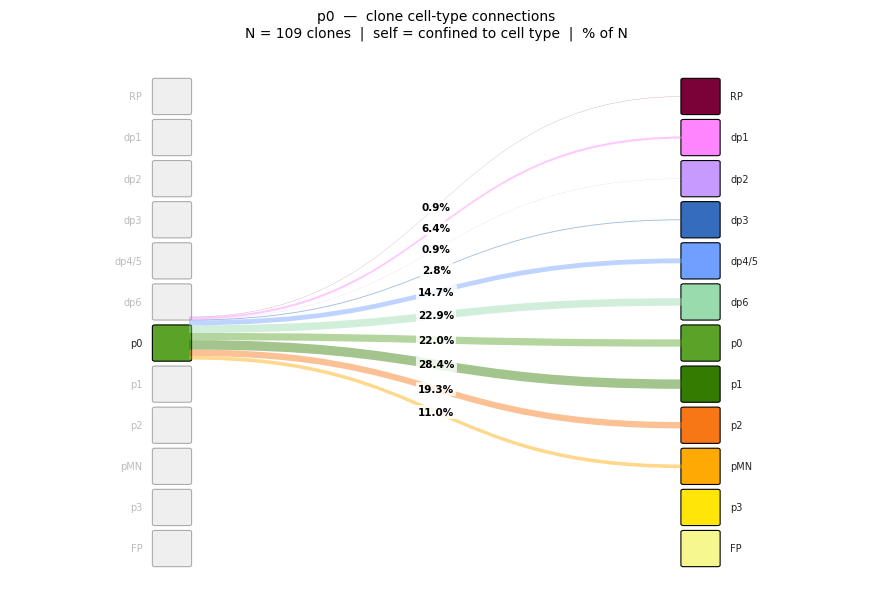

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_celltype_dp6_collapsed.pdf


<Figure size 640x480 with 0 Axes>

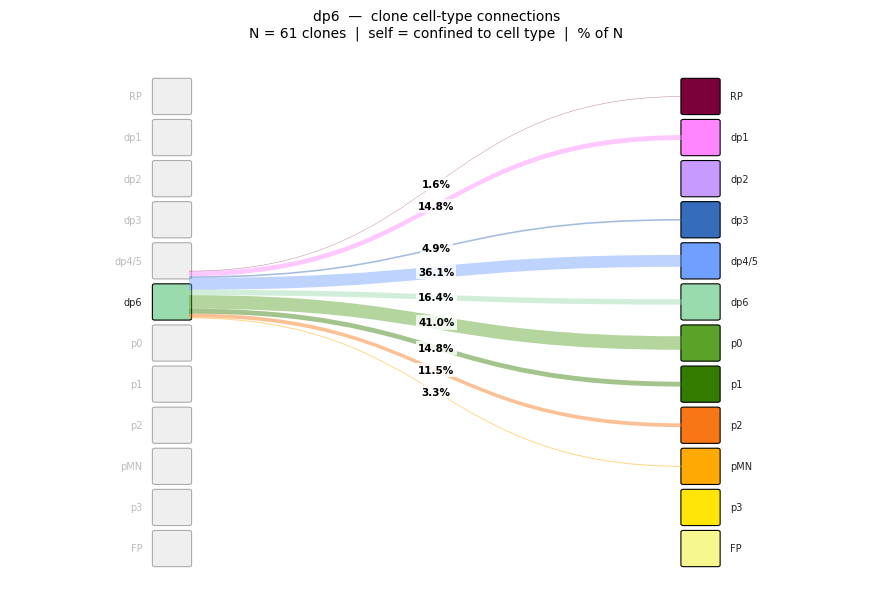

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_celltype_dp4_5_collapsed.pdf


<Figure size 640x480 with 0 Axes>

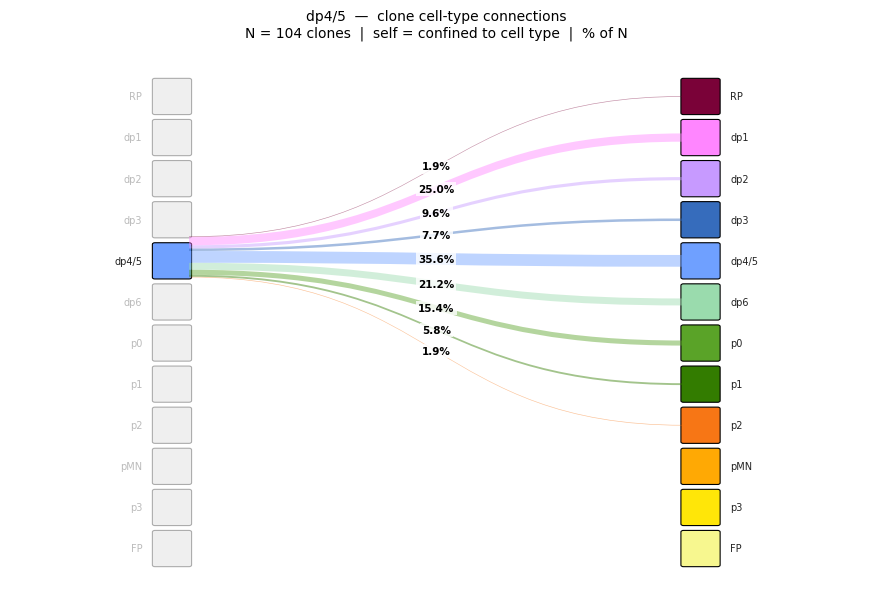

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_celltype_dp3_collapsed.pdf


<Figure size 640x480 with 0 Axes>

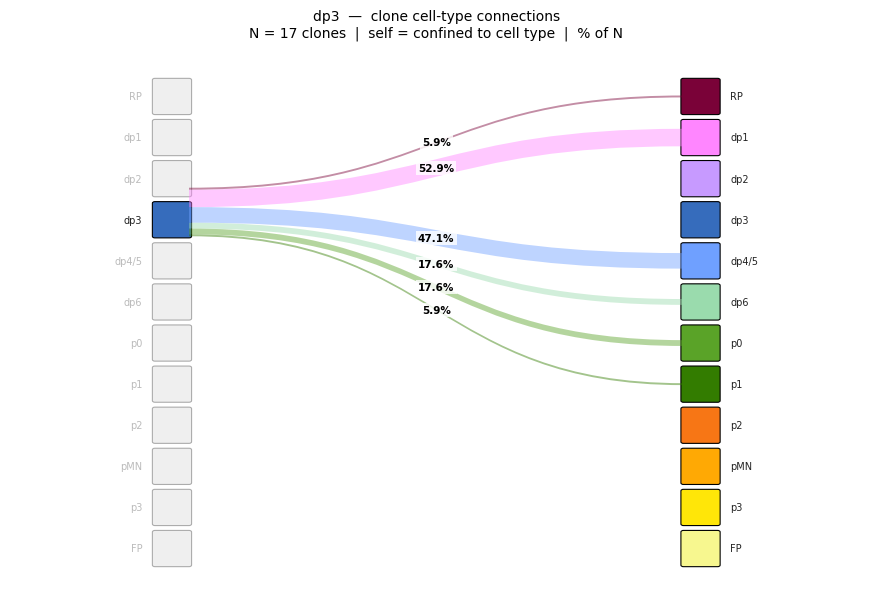

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_celltype_dp2_collapsed.pdf


<Figure size 640x480 with 0 Axes>

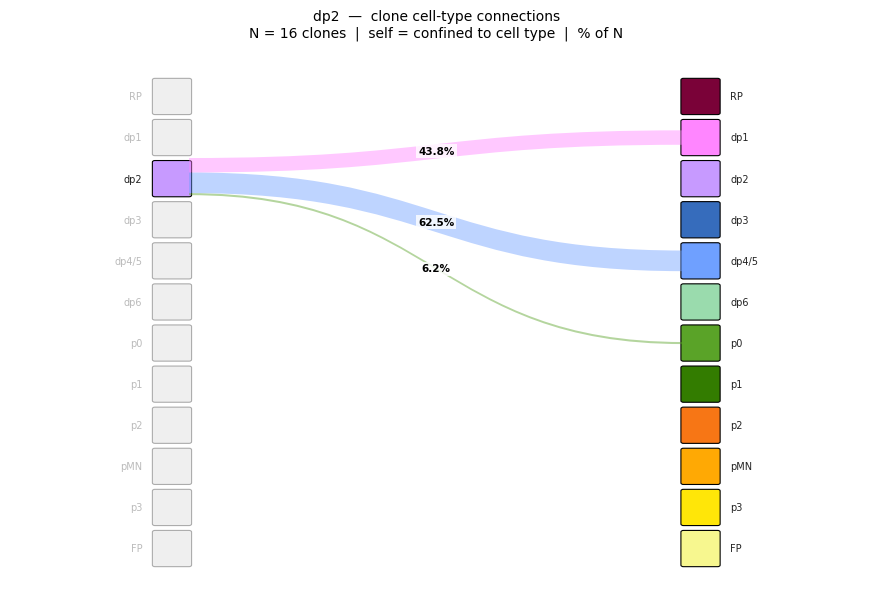

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_celltype_dp1_collapsed.pdf


<Figure size 640x480 with 0 Axes>

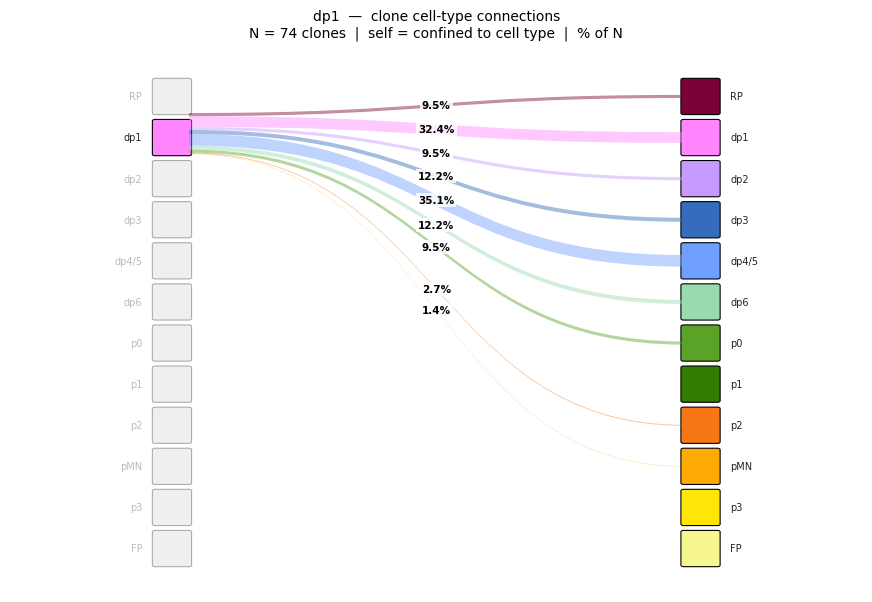

Saved: /nemo/lab/briscoej/home/users/boeziog/LARRY/LARRY_spinal_cord/Jupyter_notebooks/plots/chicken/Ashley/NT_1-somite_4-somites_7-somites/sankey_celltype_RP_collapsed.pdf


<Figure size 640x480 with 0 Axes>

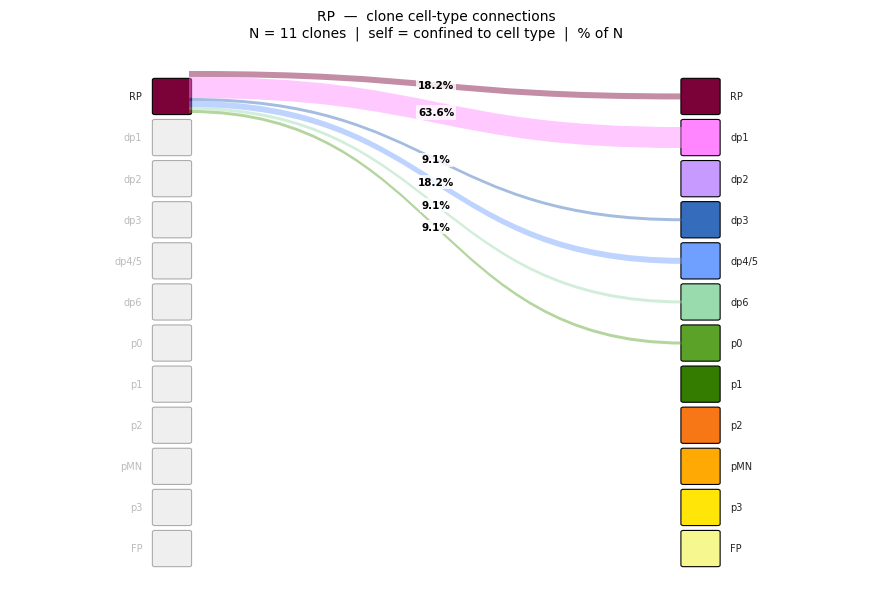

<Figure size 640x480 with 0 Axes>

In [20]:
# ── Cell-type Sankey ───────────────────────────────────────────────────────────
# DV order — only types present in cell_types_interest are kept
_dv_order = [
    "FP", "V3", "p3", "pMN", "MN", "V2", "p2",
    "V0/V1", "p1", "p0", "dp6", "dI4/dI5", "dp4/5", "dp3",
    "dp2", "dI2", "dp1", "dI1", "RP",
]
node_types = [ct for ct in _dv_order if ct in cell_types_interest]

# Colour each node by its subdivision
node_palette = {
    "RP":    "#7a0238",
    "dp1":   "#ff86ff",
    "dp2":   "#c79aff",
    "dp3":   "#366cbc",
    "dp4/5": "#6fa0ff",
    "dp6":   "#9adbad",
    "p0":    "#5aa328",
    "p1":    "#337c00",
    "p2":    "#f77615",
    "pMN":   "#ffa904",
    "p3":    "#ffe608",
    "FP":    "#f7f78f",
}

# Multi-cell data
_ct_cols = [c for c in node_types if c in clone_celltype_combo_wide.columns]
cn_ct = clone_celltype_combo_wide[_ct_cols].copy()
cn_ct = cn_ct[cn_ct.sum(axis=1) >= 2]
cn_ct = cn_ct.rename(columns={c: f"n_{c}" for c in _ct_cols})
for node in node_types:
    if f"n_{node}" not in cn_ct.columns:
        cn_ct[f"n_{node}"] = 0


def draw_celltype_sankey(focal_node):
    focal_clones = cn_ct[cn_ct[f"n_{focal_node}"] >= 1]
    N_total = len(focal_clones)
    if N_total == 0:
        print(f"No clones for {focal_node}, skipping.")
        return

    counts = {}
    for t in node_types:
        if t == focal_node:
            other = [f"n_{s}" for s in node_types if s != focal_node]
            counts[t] = int((focal_clones[other].sum(axis=1) == 0).sum())
        else:
            counts[t] = int((focal_clones[f"n_{t}"] >= 1).sum())
    pcts = {t: 100 * counts[t] / N_total for t in node_types}

    n = len(node_types)
    fig, ax = plt.subplots(figsize=(11, max(7, n * 0.55)))
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")

    nw = 0.4; xl, xr = 1.9, 8.1; y0 = 0.5; total_h = 9.0; gap = 0.15
    nh = (total_h - (n - 1) * gap) / n
    ybot = [y0 + i * (nh + gap) for i in range(n)]
    ycen = [yb + nh / 2 for yb in ybot]
    idx  = {s: i for i, s in enumerate(node_types)}

    for i, node in enumerate(node_types):
        is_focal = node == focal_node
        ax.add_patch(mpatches.FancyBboxPatch(
            (xl - nw / 2, ybot[i]), nw, nh, boxstyle="round,pad=0.03",
            facecolor=node_palette[node] if is_focal else "#CCCCCC",
            edgecolor="black", linewidth=0.8, alpha=1.0 if is_focal else 0.3,
        ))
        ax.text(xl - nw / 2 - 0.15, ycen[i], node, ha="right", va="center",
                fontsize=7, color="#222222" if is_focal else "#BBBBBB")

    for i, node in enumerate(node_types):
        ax.add_patch(mpatches.FancyBboxPatch(
            (xr - nw / 2, ybot[i]), nw, nh, boxstyle="round,pad=0.03",
            facecolor=node_palette[node], edgecolor="black", linewidth=0.8,
        ))
        ax.text(xr + nw / 2 + 0.15, ycen[i], node,
                ha="left", va="center", fontsize=7, color="#222222")

    scale = nh / N_total
    left_cursor = ybot[idx[focal_node]]
    for t in node_types:
        c = counts[t]
        if c == 0:
            continue
        fh = c * scale
        ti = idx[t]
        ly_b, ly_t = left_cursor, left_cursor + fh
        ry_b, ry_t = ycen[ti] - fh / 2, ycen[ti] + fh / 2
        _bezier_band(ax, xl + nw / 2, ly_b, ly_t, xr - nw / 2, ry_b, ry_t,
                     color=node_palette[t], alpha=0.45)
        mid_y = ((ly_b + ly_t) / 2 + (ry_b + ry_t) / 2) / 2
        ax.text(5.0, mid_y, f"{pcts[t]:.1f}%", ha="center", va="center",
                fontsize=7.5, fontweight="bold",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))
        left_cursor += fh

    ax.set_title(
        f"{focal_node}  —  clone cell-type connections\n"
        f"N = {N_total} clones  |  self = confined to cell type  |  % of N",
        fontsize=10, pad=12,
    )
    safe = focal_node.replace("/", "_")
    fname = os.path.join(figures_output, f"sankey_celltype_{safe}{analysis_suffix}.pdf")
    plt.savefig(fname, format="pdf", bbox_inches="tight")
    print(f"Saved: {fname}")
    plt.show(); plt.clf()


for fn in node_types:
    draw_celltype_sankey(fn)

In [21]:
# ── Confinement summary tables ─────────────────────────────────────────────────
rows = []
for sub in sub_order:
    focal = cn_sub[cn_sub[f"n_{sub}"] >= 1]
    N_total = len(focal)
    if N_total == 0:
        continue
    other = [f"n_{s}" for s in sub_order if s != sub]
    n_confined = int((focal[other].sum(axis=1) == 0).sum())
    n_shared = N_total - n_confined
    rows.append({"subdivision": sub, "members": ", ".join(sub_members[sub]),
                 "total_clones": N_total, "confined": n_confined, "shared": n_shared,
                 "pct_confined": round(100 * n_confined / N_total, 1),
                 "pct_shared":   round(100 * n_shared   / N_total, 1)})
confinement_sub = pd.DataFrame(rows)
print(confinement_sub.to_string(index=False))
confinement_sub.to_csv(
    os.path.join(figures_output, f"confinement_subdivisions{analysis_suffix}.csv"), index=False)

rows = []
for node in node_types:
    focal = cn_ct[cn_ct[f"n_{node}"] >= 1]
    N_total = len(focal)
    if N_total == 0:
        continue
    other = [f"n_{s}" for s in node_types if s != node]
    n_confined = int((focal[other].sum(axis=1) == 0).sum())
    n_shared = N_total - n_confined
    rows.append({"cell_type": node, "total_clones": N_total,
                 "confined": n_confined, "shared": n_shared,
                 "pct_confined": round(100 * n_confined / N_total, 1),
                 "pct_shared":   round(100 * n_shared   / N_total, 1)})
confinement_ct = pd.DataFrame(rows)
print(confinement_ct.to_string(index=False))
confinement_ct.to_csv(
    os.path.join(figures_output, f"confinement_celltypes{analysis_suffix}.csv"), index=False)

subdivision      members  total_clones  confined  shared  pct_confined  pct_shared
      Sub_1       FP, p3            10         7       3          70.0        30.0
      Sub_2      pMN, p2           123        64      59          52.0        48.0
      Sub_3  p1, p0, dp6           170        75      95          44.1        55.9
      Sub_4   dp3, dp4/5           113        41      72          36.3        63.7
      Sub_5 RP, dp1, dp2            87        37      50          42.5        57.5
cell_type  total_clones  confined  shared  pct_confined  pct_shared
       FP             4         3       1          75.0        25.0
       p3             7         3       4          42.9        57.1
      pMN            75        43      32          57.3        42.7
       p2            62        12      50          19.4        80.6
       p1            61         5      56           8.2        91.8
       p0           109        24      85          22.0        78.0
      dp6            61   

Saved confinement barplots.


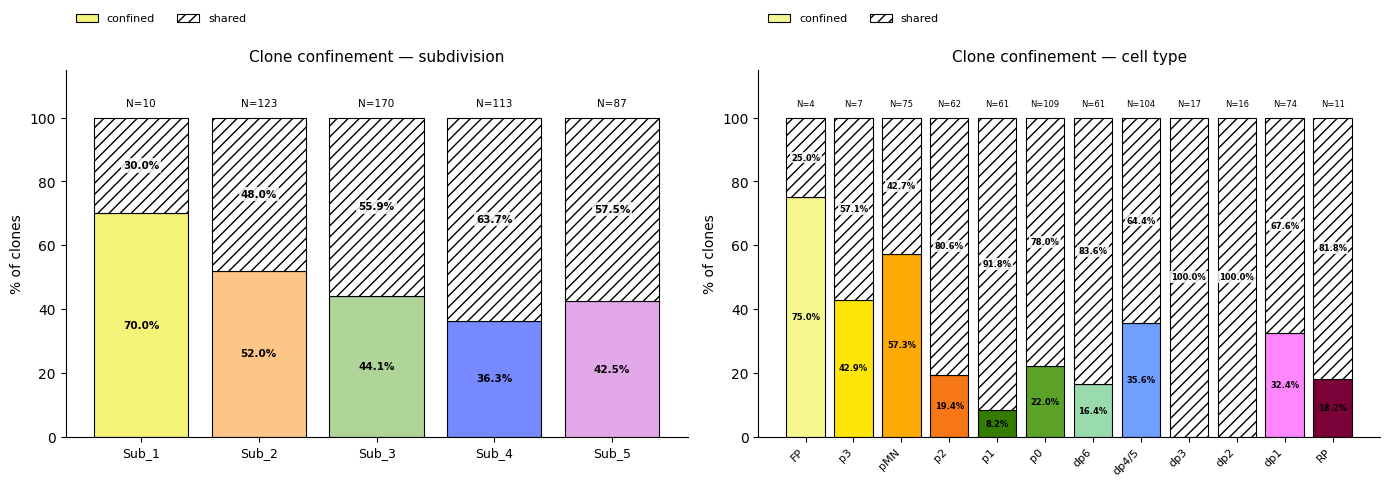

<Figure size 640x480 with 0 Axes>

In [22]:
# ── Confinement bar plots ──────────────────────────────────────────────────────

_ct_df = confinement_ct

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subdivisions
ax = axes[0]
x = list(range(len(confinement_sub)))
ax.bar(x, confinement_sub["pct_confined"],
       color=[sub_palette[s] for s in confinement_sub["subdivision"]],
       edgecolor="black", linewidth=0.8, label="confined")
ax.bar(x, confinement_sub["pct_shared"],
       bottom=confinement_sub["pct_confined"],
       color="white", edgecolor="black", linewidth=0.8, hatch="///", label="shared")
for i, row in confinement_sub.iterrows():
    if row["pct_confined"] > 5:
        ax.text(i, row["pct_confined"] / 2, f"{row['pct_confined']:.1f}%",
                ha="center", va="center", fontsize=7.5, fontweight="bold")
    if row["pct_shared"] > 5:
        ax.text(i, row["pct_confined"] + row["pct_shared"] / 2, f"{row['pct_shared']:.1f}%",
                ha="center", va="center", fontsize=7.5, fontweight="bold",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))
    ax.text(i, 103, f"N={row['total_clones']}", ha="center", va="bottom", fontsize=7.5,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))
ax.set_xticks(x)
ax.set_xticklabels(confinement_sub["subdivision"], fontsize=9)
ax.set_ylabel("% of clones", fontsize=10)
ax.set_ylim(0, 115)
ax.set_title("Clone confinement — subdivision", fontsize=11)
ax.legend(loc="upper left", bbox_to_anchor=(0, 1.18), ncol=2, fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

# Cell types
ax = axes[1]
x = list(range(len(_ct_df)))
ax.bar(x, _ct_df["pct_confined"],
       color=[node_palette[n] for n in _ct_df["cell_type"]],
       edgecolor="black", linewidth=0.8, label="confined")
ax.bar(x, _ct_df["pct_shared"],
       bottom=_ct_df["pct_confined"],
       color="white", edgecolor="black", linewidth=0.8, hatch="///", label="shared")
for i, row in _ct_df.iterrows():
    if row["pct_confined"] > 5:
        ax.text(i, row["pct_confined"] / 2, f"{row['pct_confined']:.1f}%",
                ha="center", va="center", fontsize=6, fontweight="bold")
    if row["pct_shared"] > 5:
        ax.text(i, row["pct_confined"] + row["pct_shared"] / 2, f"{row['pct_shared']:.1f}%",
                ha="center", va="center", fontsize=6, fontweight="bold",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1))
    ax.text(i, 103, f"N={row['total_clones']}", ha="center", va="bottom", fontsize=6,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1))
ax.set_xticks(x)
ax.set_xticklabels(_ct_df["cell_type"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("% of clones", fontsize=10)
ax.set_ylim(0, 115)
ax.set_title("Clone confinement — cell type", fontsize=11)
ax.legend(loc="upper left", bbox_to_anchor=(0, 1.18), ncol=2, fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(figures_output, f"confinement_barplots{analysis_suffix}.pdf"),
            format="pdf", bbox_inches="tight")
print("Saved confinement barplots.")
plt.show(); plt.clf()
